<a href="https://colab.research.google.com/github/TayyabKhan54/Machine-learning-project-/blob/main/ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_excel('//content/students_dataset.xlsx')

In [ ]:
df.head()

,Student_ID,Name,Class,Age,IQ,CGPA,Placement_Status
0,S001,Student_1,10th,16,130,3.12,Yes
1,S002,Student_2,11th,17,85,3.63,No
2,S003,Student_3,11th,17,117,3.31,Yes
3,S004,Student_4,11th,17,100,3.80,No
4,S005,Student_5,10th,15,120,2.20,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        100 non-null    object 
 1   Name              100 non-null    object 
 2   Class             100 non-null    object 
 3   Age               100 non-null    int64  
 4   IQ                100 non-null    int64  
 5   CGPA              100 non-null    float64
 6   Placement_Status  100 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 5.6+ KB


In [ ]:
df.shape

(100, 7)

In [ ]:
df=df.iloc[:,3:]

In [ ]:
df.head()

,Age,IQ,CGPA,Placement_Status
0,16,130,3.12,Yes
1,17,85,3.63,No
2,17,117,3.31,Yes
3,17,100,3.80,No
4,15,120,2.20,No


In [ ]:
import matplotlib.pyplot as plt


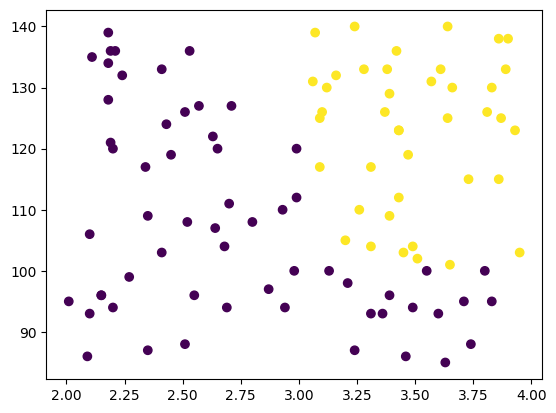

In [ ]:
df['Placement_Status_Numeric'] = df['Placement_Status'].map({'Yes': 1, 'No': 0})
plt.scatter(df['CGPA'], df['IQ'], c=df['Placement_Status_Numeric'])

# extract+EDA+feature **selection**

In [ ]:
X=df.iloc[:,1:3]
y=df.iloc[:,-1]

In [ ]:
X

,IQ,CGPA
0,130,3.12
1,85,3.63
2,117,3.31
3,100,3.80
4,120,2.20
...,...,...
95,126,3.37
96,130,3.83
97,136,2.53
98,86,3.46


In [ ]:
y.shape

(100,)

# Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
X_train

,IQ,CGPA
99,108,2.80
25,103,3.95
24,93,3.36
33,93,3.31
71,132,3.16
...,...,...
80,88,3.74
10,140,3.24
76,133,3.28
14,115,3.86


In [ ]:
y_train

,Placement_Status_Numeric
99,0
25,1
24,0
33,0
71,1
...,...
80,0
10,1
76,1
14,1


In [ ]:
X_test

,IQ,CGPA
18,108,2.52
79,94,2.20
26,139,3.07
98,86,3.46
47,93,3.60
4,120,2.20
45,119,3.47
77,87,3.24
1,85,3.63
53,104,3.31


# scale the value

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler =StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-0.43934881, -0.45396214],
       [-0.75316939,  1.53766955],
       [-1.38081055,  0.5158759 ],
       [-1.38081055,  0.42928322],
       [ 1.06698997,  0.16950518],
       [-0.69040528,  0.74101688],
       [-1.82015936, -1.68357822],
       [ 0.12552823,  0.42928322],
       [-1.1925182 , -0.88692555],
       [ 1.12975409,  1.43375834],
       [ 1.50633878, -1.5277114 ],
       [-1.31804644,  0.74101688],
       [ 1.12975409, -1.12938506],
       [ 0.62764116,  0.04827542],
       [ 0.75316939, -0.60982896],
       [ 1.1925182 , -1.5277114 ],
       [ 0.50211293,  0.63710566],
       [-1.00422586, -1.37184457],
       [ 0.3765847 , -1.51039286],
       [ 0.87869762,  0.56783151],
       [ 0.31382058, -0.12490994],
       [ 0.50211293,  0.63710566],
       [-0.75316939,  0.67174273],
       [ 0.81593351, -1.5277114 ],
       [ 0.69040528,  0.53319444],
       [-0.18829235, -0.12490994],
       [-1.25528232, -1.82212652],
       [-0.81593351,  0.77565395],
       [ 1.31804644,

In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
X_test

array([[-0.43934881, -0.93888116],
       [-1.31804644, -1.49307432],
       [ 1.50633878,  0.01363835],
       [-1.82015936,  0.68906127],
       [-1.38081055,  0.93152078],
       [ 0.31382058, -1.49307432],
       [ 0.25105646,  0.70637981],
       [-1.75739525,  0.30805347],
       [-1.88292348,  0.98347639],
       [-0.69040528,  0.42928322],
       [-1.25528232,  1.12202468],
       [ 0.69040528,  0.06559396],
       [-0.69040528, -0.66178457],
       [ 0.56487704, -1.09474799],
       [ 0.94146174,  1.32984712],
       [-0.56487704, -1.66625969],
       [-1.1925182 , -1.57966701],
       [ 1.31804644, -0.92156262],
       [-0.75316939, -1.12938506],
       [ 0.75316939, -0.85228847]])

# train the model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
#model traning
clf.fit(X_train,y_train)

LogisticRegression()

# Evaluate the model or model selection

In [ ]:
#check accuricy
y_pred = clf.predict(X_test)

In [ ]:
y_test

,Placement_Status_Numeric
18,0
79,0
26,1
98,0
47,0
4,0
45,1
77,0
1,0
53,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.9

In [ ]:
#ye ham na as liyi use keya kha ke LM na ko sa pattren note keya kha
from mlxtend.plotting import plot_decision_regions

<Axes: >

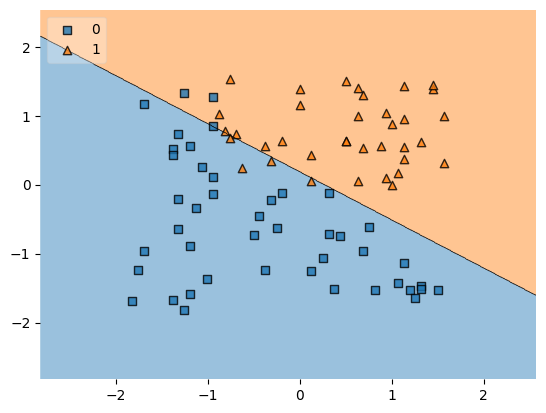

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [ ]:
import pickle

In [ ]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))